In [170]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, chi2_contingency, mannwhitneyu, levene, kruskal

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import PredictionErrorDisplay

# Učitavanje i predobrada podataka

In [171]:
file_path = 'Customer Churn.csv'

data = pd.read_csv(file_path)

In [172]:
print(data.head())
print(data.info())
print(data.dtypes)
print(data.describe())

   Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0              8          0                    38               0   
1              0          0                    39               0   
2             10          0                    37               0   
3             10          0                    38               0   
4              3          0                    38               0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2                       24          3    

Dataset se sastoji od podataka o korisnicima telekomunikacijske usluge.
Stupci opisuju ponašanje korisnika, trajanje pretplate, količinu korištenja usluge, dob, vrijednost korisnika i varijablu Churn koja označava je li korisnik napustio uslugu.

Većina varijabli je numerička, dok se varijable kao što su Complains, Tariff Plan, Status, Age Group i Churn mogu promatrati kao kategoričke varijable zapisane brojevima.
Za daljnju analizu posebno će se promatrati varijable Customer Value i Churn, jer je cilj razumjeti razlike između korisnika koji ostaju i korisnika koji napuštaju uslugu.

In [173]:
print(data.isna().sum())

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64


In [174]:
print(data['Churn'].unique())
print(data['Complains'].unique())
print(data['Tariff Plan'].unique())
print(data['Status'].unique())
print(data['Age Group'].unique())

[0 1]
[0 1]
[1 2]
[1 2]
[3 2 1 4 5]


Provjerom jedinstvenih vrijednosti vidimo da je Churn binarna varijabla.
Vrijednost 0 predstavlja korisnike koji nisu napustili uslugu, dok vrijednost 1 predstavlja korisnike koji su napustili uslugu.
Isto tako, Complains, Tariff Plan i Status su kategoričke varijable zapisane brojevima.

In [175]:
not_churn = data[data['Churn'] == 0]
churn = data[data['Churn'] == 1]

print(not_churn.head())
print(churn.head())

   Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0              8          0                    38               0   
1              0          0                    39               0   
2             10          0                    37               0   
3             10          0                    38               0   
4              3          0                    38               0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2                       24          3    

Uzimamo dva uzorka iz podatkovnog skupa: korisnike koji nisu napustili uslugu i korisnike koji jesu napustili uslugu.
Na ovaj način možemo usporediti njihove vrijednosti i provjeriti postoji li statistički značajna razlika između dvije skupine.

In [176]:
data['customer_value_type'] = np.where(data['Customer Value'] < data['Customer Value'].median(), 'low', 'high')
data['usage_type'] = np.where(data['Seconds of Use'] < data['Seconds of Use'].median(), 'low', 'high')

data.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn,customer_value_type,usage_type
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,low,high
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,low,low
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,high,low
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,high,high
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,low,low


Dodatno stvaramo dvije nove kategoričke varijable.
Varijabla customer_value_type označava ima li korisnik nisku ili visoku vrijednost u odnosu na medijan varijable Customer Value.
Varijabla usage_type označava ima li korisnik nisku ili visoku razinu korištenja usluge u odnosu na medijan varijable Seconds of Use.

# EDA i statistički testovi

U ovom istraživanju posebna pažnja stavlja se na varijablu Customer Value.
Ta varijabla predstavlja vrijednost korisnika i može biti važna za razumijevanje korisnika koji ostaju ili napuštaju uslugu.

Mjere središnje tendencije za Customer Value: 
Aritmetička sredina:  470.9729158730159
Median:  228.48
Mod:  0    0.0
Name: Customer Value, dtype: float64

Mjere disperzije za Customer Value
count    3150.000000
mean      470.972916
std       517.015433
min         0.000000
25%       113.801250
50%       228.480000
75%       788.388750
max      2165.280000
Name: Customer Value, dtype: float64

Mjere oblika distribucije za Customer Value: 
Asimetrija:  1.426611857438812
Spljoštenost:  1.2206495810976135


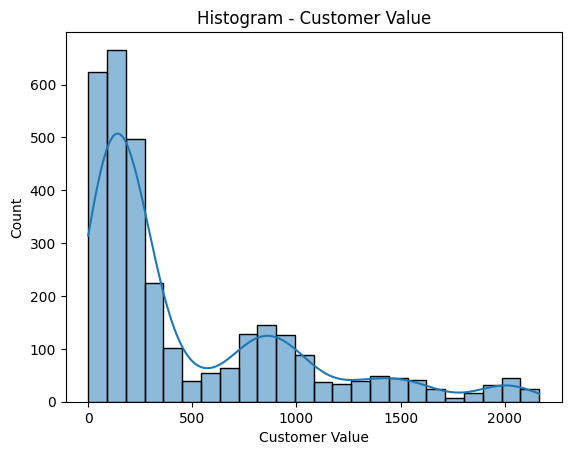

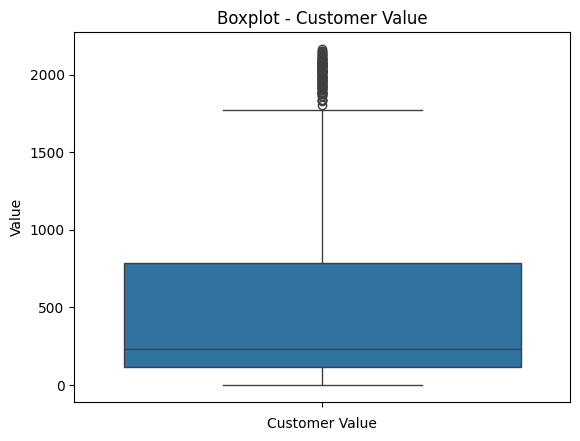

In [177]:
print('Mjere središnje tendencije za Customer Value: ')
print('Aritmetička sredina: ', data['Customer Value'].mean())
print('Median: ', data['Customer Value'].median())
print('Mod: ', data['Customer Value'].mode())

print('\nMjere disperzije za Customer Value')
print(data['Customer Value'].describe())

print('\nMjere oblika distribucije za Customer Value: ')
print('Asimetrija: ', skew(data['Customer Value']))
print('Spljoštenost: ', kurtosis(data['Customer Value']))

sns.histplot(data=data['Customer Value'], kde=True)
plt.title('Histogram - Customer Value')
plt.ylabel('Count')
plt.xlabel('Customer Value')
plt.show()

sns.boxplot(data['Customer Value'])
plt.title('Boxplot - Customer Value')
plt.ylabel('Value')
plt.xlabel('Customer Value')
plt.show()

Iz histograma i boxplota može se vidjeti da varijabla Customer Value nije pravilno normalno distribuirana.
Vrijednosti su asimetrično raspoređene i postoje veće vrijednosti koje odstupaju od ostatka podataka.
Zbog toga je potrebno dodatno provjeriti normalnost statističkim testom.

In [178]:
continuous_columns = [
    'Call  Failure',
    'Subscription  Length',
    'Charge  Amount',
    'Seconds of Use',
    'Frequency of use',
    'Frequency of SMS',
    'Distinct Called Numbers',
    'Age',
    'Customer Value'
]

for column in continuous_columns:
    shapiro_stat, shapiro_p = shapiro(data[column])
    print(f"Shapiro-Wilk statistika za {column}: {shapiro_stat:.4f}, P-vrijednost: {shapiro_p:.4f}")

    if shapiro_p > 0.05:
        print(f"Varijabla {column} približno je normalno distribuirana.")
    else:
        print(f"Varijabla {column} nije normalno distribuirana.")

Shapiro-Wilk statistika za Call  Failure: 0.8907, P-vrijednost: 0.0000
Varijabla Call  Failure nije normalno distribuirana.
Shapiro-Wilk statistika za Subscription  Length: 0.8760, P-vrijednost: 0.0000
Varijabla Subscription  Length nije normalno distribuirana.
Shapiro-Wilk statistika za Charge  Amount: 0.6575, P-vrijednost: 0.0000
Varijabla Charge  Amount nije normalno distribuirana.
Shapiro-Wilk statistika za Seconds of Use: 0.8456, P-vrijednost: 0.0000
Varijabla Seconds of Use nije normalno distribuirana.
Shapiro-Wilk statistika za Frequency of use: 0.8960, P-vrijednost: 0.0000
Varijabla Frequency of use nije normalno distribuirana.
Shapiro-Wilk statistika za Frequency of SMS: 0.6817, P-vrijednost: 0.0000
Varijabla Frequency of SMS nije normalno distribuirana.
Shapiro-Wilk statistika za Distinct Called Numbers: 0.9309, P-vrijednost: 0.0000
Varijabla Distinct Called Numbers nije normalno distribuirana.
Shapiro-Wilk statistika za Age: 0.7709, P-vrijednost: 0.0000
Varijabla Age nije no

Normalnost distribucije provjerena je Shapiro-Wilkovim testom.
Nulta hipoteza testa je da su podaci normalno distribuirani, dok je alternativna hipoteza da podaci nisu normalno distribuirani.
Ako je p-vrijednost manja od 0.05, odbacujemo nultu hipotezu i zaključujemo da podaci nisu normalno distribuirani.

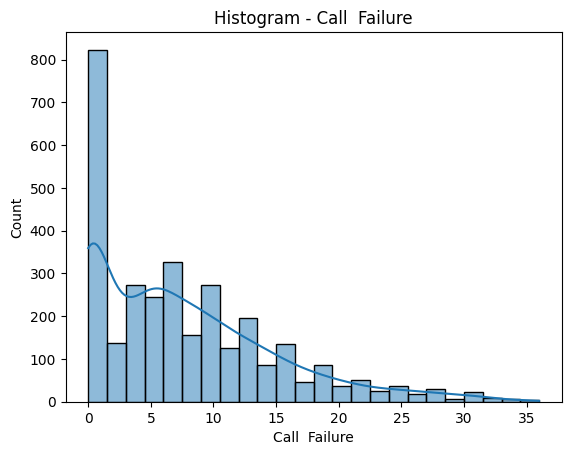

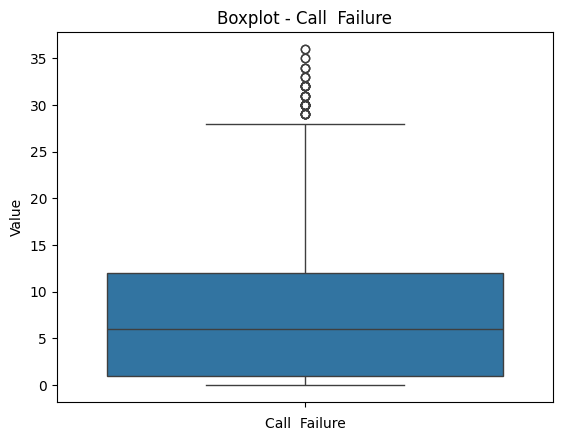

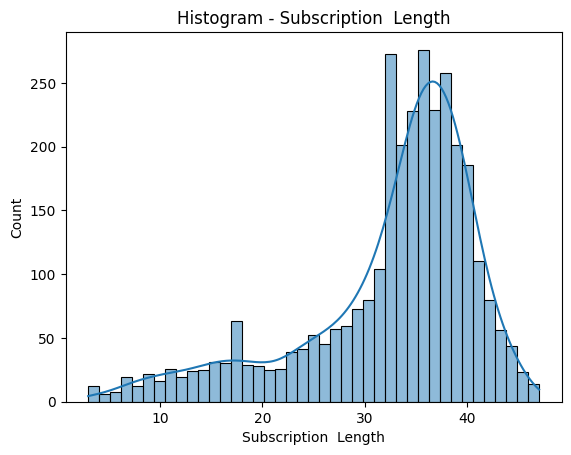

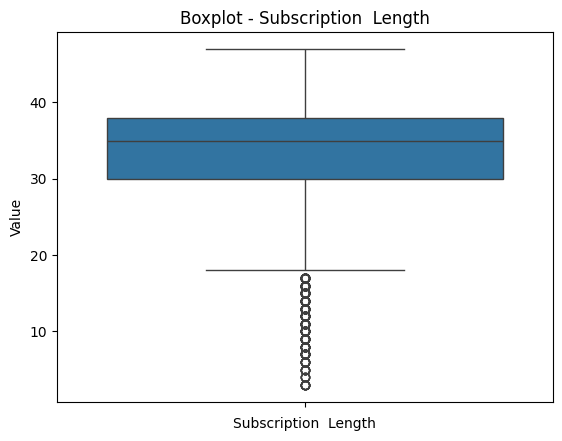

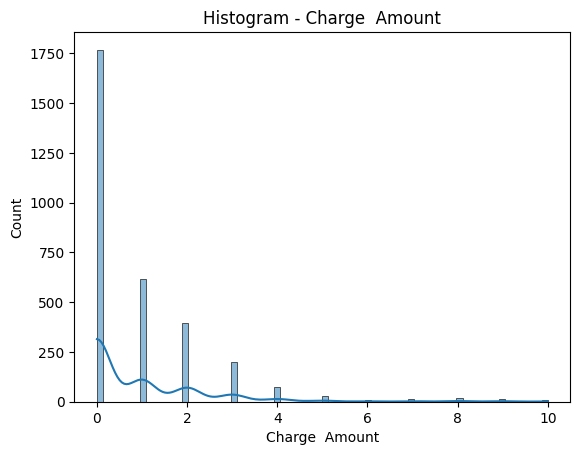

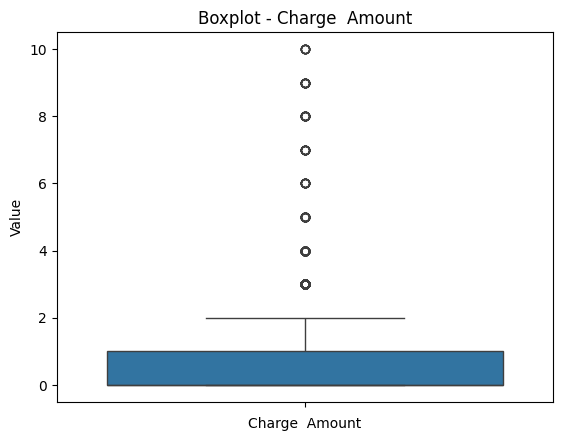

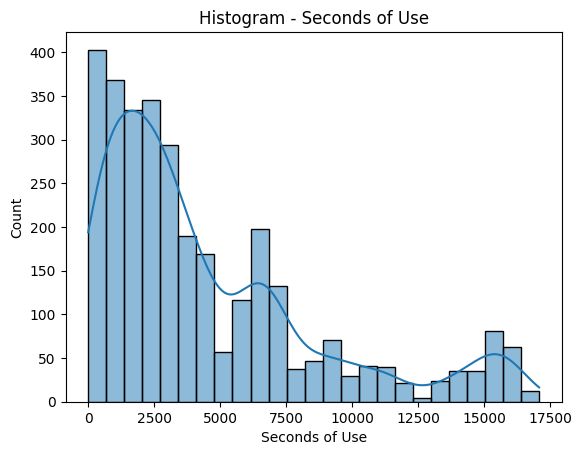

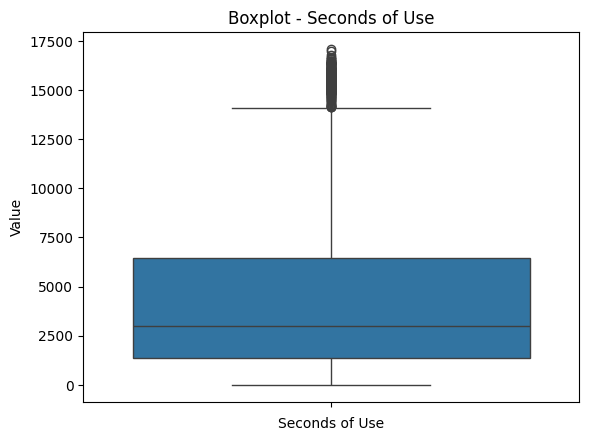

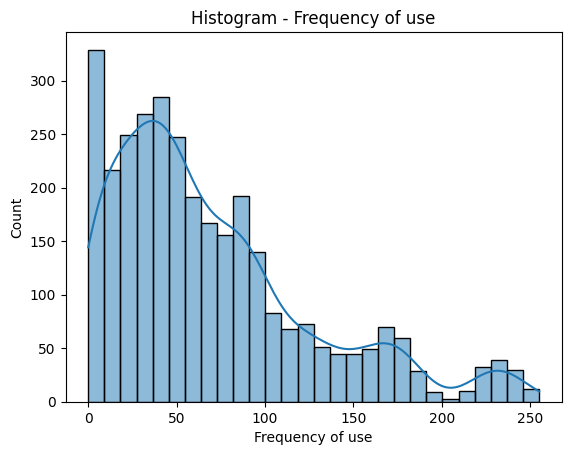

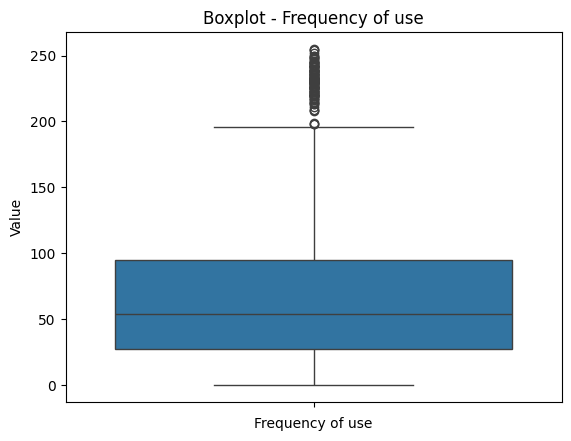

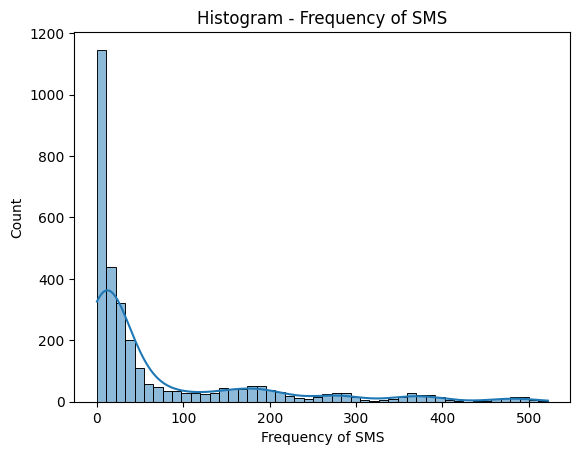

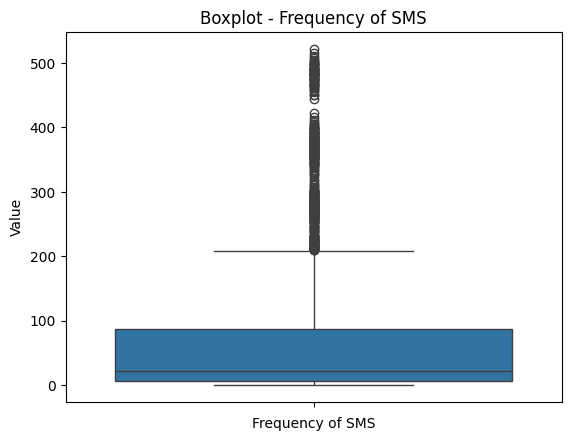

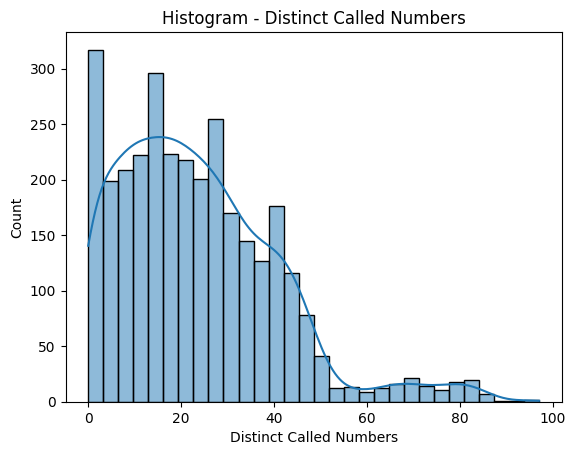

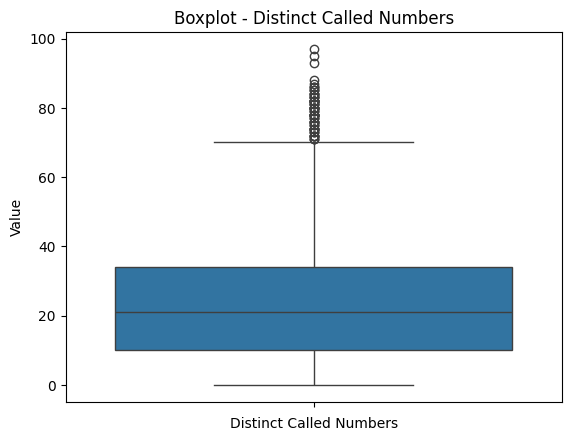

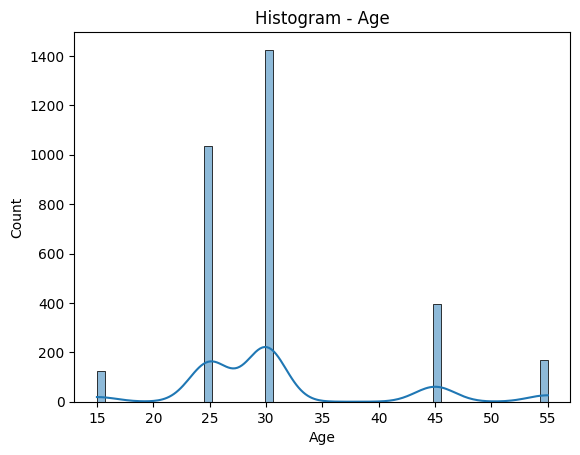

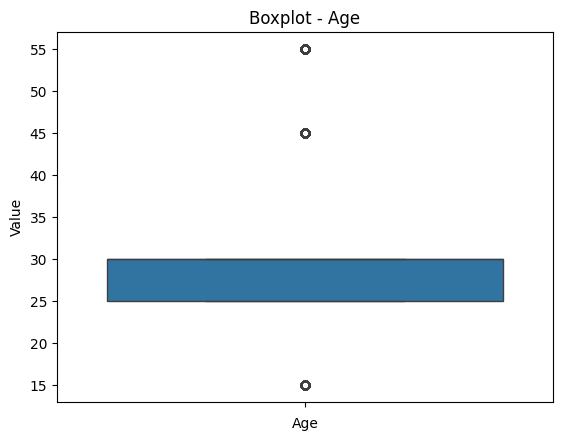

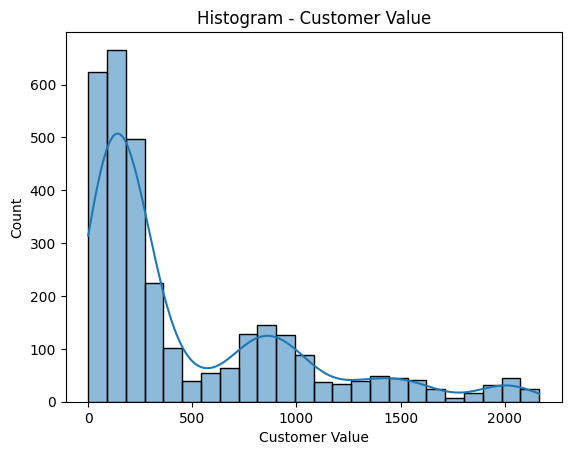

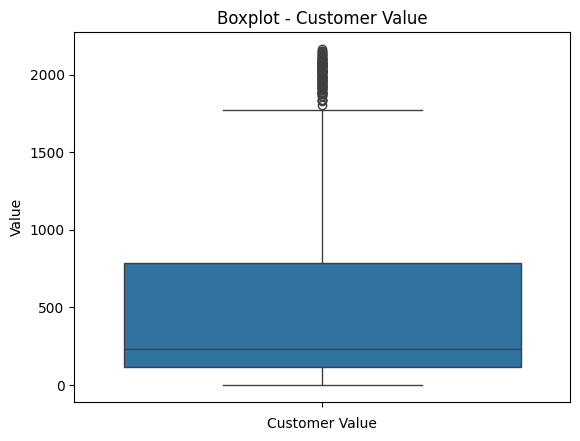

In [179]:
for column in continuous_columns:
    sns.histplot(data=data[column], kde=True)
    title = 'Histogram - ' + column
    plt.title(title)
    plt.ylabel('Count')
    plt.xlabel(column)
    plt.show()

    sns.boxplot(data[column])
    title = 'Boxplot - ' + column
    plt.title(title)
    plt.ylabel('Value')
    plt.xlabel(column)
    plt.show()

Vizualizacijom promatranih varijabli možemo bolje vidjeti oblik distribucije.
Histogrami i boxplotovi potvrđuju da se radi o varijablama koje uglavnom ne prate normalnu distribuciju.

Sljedeći korak je usporediti korisnike koji su napustili uslugu i korisnike koji nisu napustili uslugu.
Promatrat će se varijabla Customer Value kako bi se provjerilo postoji li statistički značajna razlika između te dvije skupine.

In [180]:
not_churn_value = not_churn['Customer Value']
churn_value = churn['Customer Value']

shapiro_not_churn = stats.shapiro(not_churn_value).pvalue
shapiro_churn = stats.shapiro(churn_value).pvalue

print(f"Shapiro p-vrijednost za korisnike koji nisu napustili uslugu: {shapiro_not_churn}")
print(f"Shapiro p-vrijednost za korisnike koji su napustili uslugu: {shapiro_churn}")

Shapiro p-vrijednost za korisnike koji nisu napustili uslugu: 1.788354795889192e-46
Shapiro p-vrijednost za korisnike koji su napustili uslugu: 1.9934518465199024e-25


Prvo je potrebno provjeriti jesu li podaci normalno distribuirani u obje skupine.
Ako barem jedna skupina ne prati normalnu distribuciju, tada nije prikladno koristiti parametarski t-test, nego neparametarski Mann-Whitney U test.

In [181]:
print(stats.levene(not_churn_value, churn_value))

LeveneResult(statistic=np.float64(239.04186256275227), pvalue=np.float64(4.9642216033233806e-52))


Leveneov test koristi se za provjeru jednakosti varijanci između dvije skupine.
Ako je p-vrijednost manja od 0.05, zaključujemo da pretpostavka jednakosti varijanci nije zadovoljena.

In [182]:
u, p = stats.mannwhitneyu(not_churn_value, churn_value)

print("U =", u, " p =", p)

if p < 0.05:
    print("Odbacuje se nulta hipoteza")
else:
    print("Ne odbacuje se nulta hipoteza")

U = 1033434.0  p = 2.992856770049604e-91
Odbacuje se nulta hipoteza


Mann-Whitney U test koristi se jer podaci ne prate normalnu distribuciju.
Nulta hipoteza je da ne postoji statistički značajna razlika u vrijednosti korisnika između korisnika koji su napustili uslugu i korisnika koji nisu napustili uslugu.
Ako je p-vrijednost manja od 0.05, odbacujemo nultu hipotezu i zaključujemo da postoji statistički značajna razlika između promatranih skupina.

Prosječna vrijednost Customer Value za korisnike koji nisu napustili uslugu: 535.5115009416196
Prosječna vrijednost Customer Value za korisnike koji su napustili uslugu: 124.81141414141413


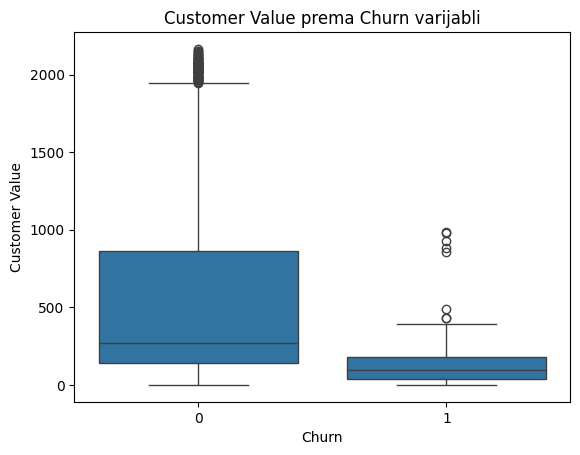

In [183]:
print("Prosječna vrijednost Customer Value za korisnike koji nisu napustili uslugu:", not_churn_value.mean())
print("Prosječna vrijednost Customer Value za korisnike koji su napustili uslugu:", churn_value.mean())

sns.boxplot(x='Churn', y='Customer Value', data=data)
plt.title('Customer Value prema Churn varijabli')
plt.xlabel('Churn')
plt.ylabel('Customer Value')
plt.show()

Iz usporedbe srednjih vrijednosti i boxplota može se vidjeti da se korisnici koji nisu napustili uslugu razlikuju od korisnika koji su napustili uslugu prema varijabli Customer Value.

Churn         0    1
Complains           
0          2614  295
1            41  200
Chi-square statistika: 886.2116236265656, P-vrijednost: 9.75604260522434e-195
Odbacujemo nul hipotezu


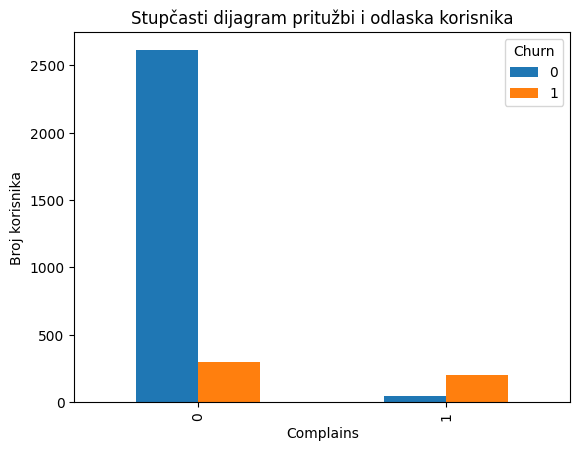

In [184]:
contingency_table = pd.crosstab(data['Complains'], data['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(contingency_table)
print(f"Chi-square statistika: {chi2}, P-vrijednost: {p}")

if p < 0.05:
    print("Odbacujemo nul hipotezu")
else:
    print("Ne odbacujemo nul hipotezu")

contingency_table.plot(kind='bar')
plt.title('Stupčasti dijagram pritužbi i odlaska korisnika')
plt.ylabel('Broj korisnika')
plt.xlabel('Complains')
plt.show()

Chi-square testom provjerava se postoji li statistički značajna povezanost između pritužbi korisnika i odlaska korisnika.
Nulta hipoteza je da ne postoji povezanost između varijabli Complains i Churn.
Ako je p-vrijednost manja od 0.05, odbacujemo nultu hipotezu i zaključujemo da postoji statistički značajna povezanost.

Churn      0    1
Status           
1       2243  125
2        412  370
Chi-square statistika: 781.1059516791336, P-vrijednost: 6.918764667789738e-172
Odbacujemo nul hipotezu


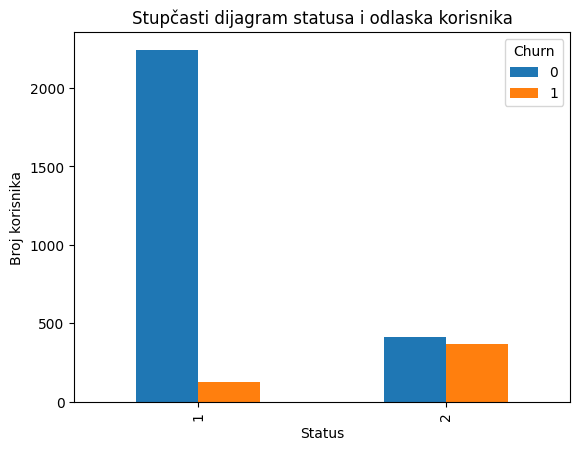

In [185]:
contingency_table = pd.crosstab(data['Status'], data['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(contingency_table)
print(f"Chi-square statistika: {chi2}, P-vrijednost: {p}")

if p < 0.05:
    print("Odbacujemo nul hipotezu")
else:
    print("Ne odbacujemo nul hipotezu")

contingency_table.plot(kind='bar')
plt.title('Stupčasti dijagram statusa i odlaska korisnika')
plt.ylabel('Broj korisnika')
plt.xlabel('Status')
plt.show()

Dodatno se promatra povezanost između varijable Status i Churn.
Na taj način možemo provjeriti razlikuje li se učestalost odlaska korisnika ovisno o statusu korisnika.

# Izrada linearnog modela za predviđanje vrijednosti korisnika

Kako bismo izradili model koji predviđa vrijednost korisnika, potrebno je prvo provjeriti veze između numeričkih varijabli.
To radimo računanjem korelacije.

Pearson Correlation Matrix:
                         Customer Value  Seconds of Use  Frequency of use  \
Customer Value                 1.000000        0.415087          0.401572   
Seconds of Use                 0.415087        1.000000          0.946489   
Frequency of use               0.401572        0.946489          1.000000   
Frequency of SMS               0.924877        0.102123          0.100019   
Distinct Called Numbers        0.284807        0.676536          0.736114   
Call  Failure                  0.121225        0.501607          0.573349   
Subscription  Length           0.109565        0.124618          0.106534   
Charge  Amount                 0.169428        0.446738          0.379096   
Age                           -0.220362        0.020843         -0.028350   

                         Frequency of SMS  Distinct Called Numbers  \
Customer Value                   0.924877                 0.284807   
Seconds of Use                   0.102123                 0.6

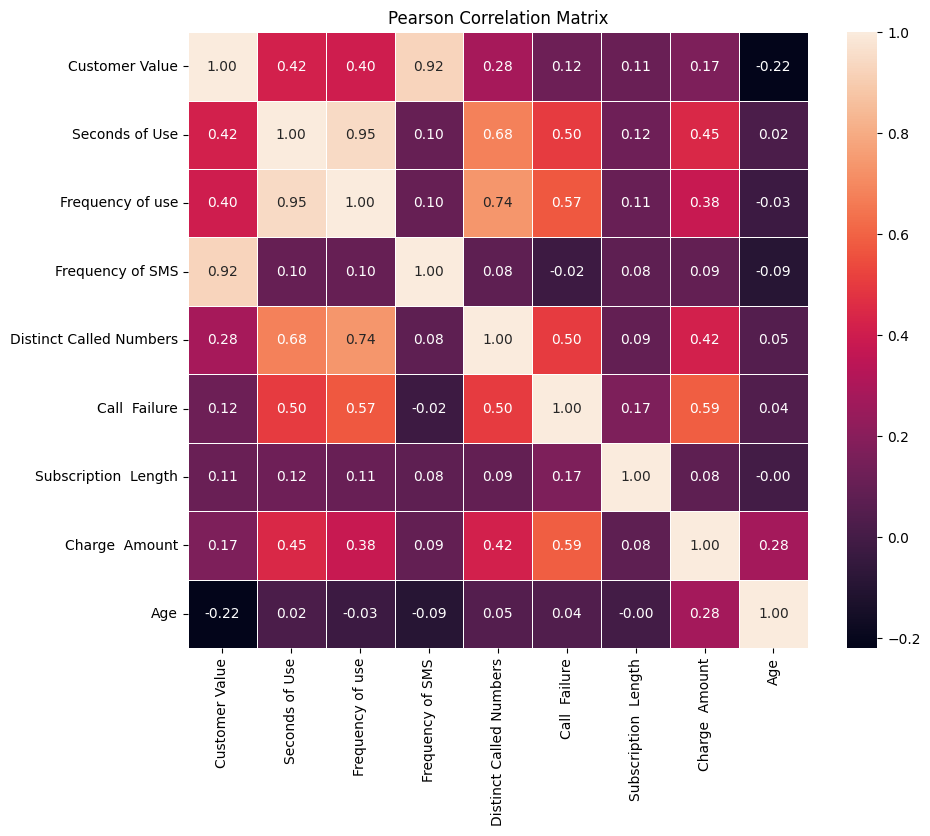

In [186]:
data_linear = data[['Customer Value', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Call  Failure', 'Subscription  Length', 'Charge  Amount', 'Age']].copy()

correlation_matrix = data_linear.corr(method='pearson')
print("Pearson Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix')
plt.show()

Pearsonova korelacija daje uvid u linearnu povezanost između dvije varijable.
Ako je vrijednost korelacije blizu 1, postoji jaka pozitivna linearna povezanost.
Ako je vrijednost korelacije blizu -1, postoji jaka negativna linearna povezanost.
Ako je vrijednost korelacije blizu 0, ne postoji jaka linearna povezanost.

Spearman Correlation Matrix:
                         Customer Value  Seconds of Use  Frequency of use  \
Customer Value                 1.000000        0.713936          0.672600   
Seconds of Use                 0.713936        1.000000          0.937015   
Frequency of use               0.672600        0.937015          1.000000   
Frequency of SMS               0.779590        0.308089          0.305579   
Distinct Called Numbers        0.562548        0.762827          0.824217   
Call  Failure                  0.346104        0.465648          0.550034   
Subscription  Length           0.144779        0.145197          0.174257   
Charge  Amount                 0.393407        0.489690          0.446959   
Age                           -0.157686        0.014530         -0.039713   

                         Frequency of SMS  Distinct Called Numbers  \
Customer Value                   0.779590                 0.562548   
Seconds of Use                   0.308089                 0.

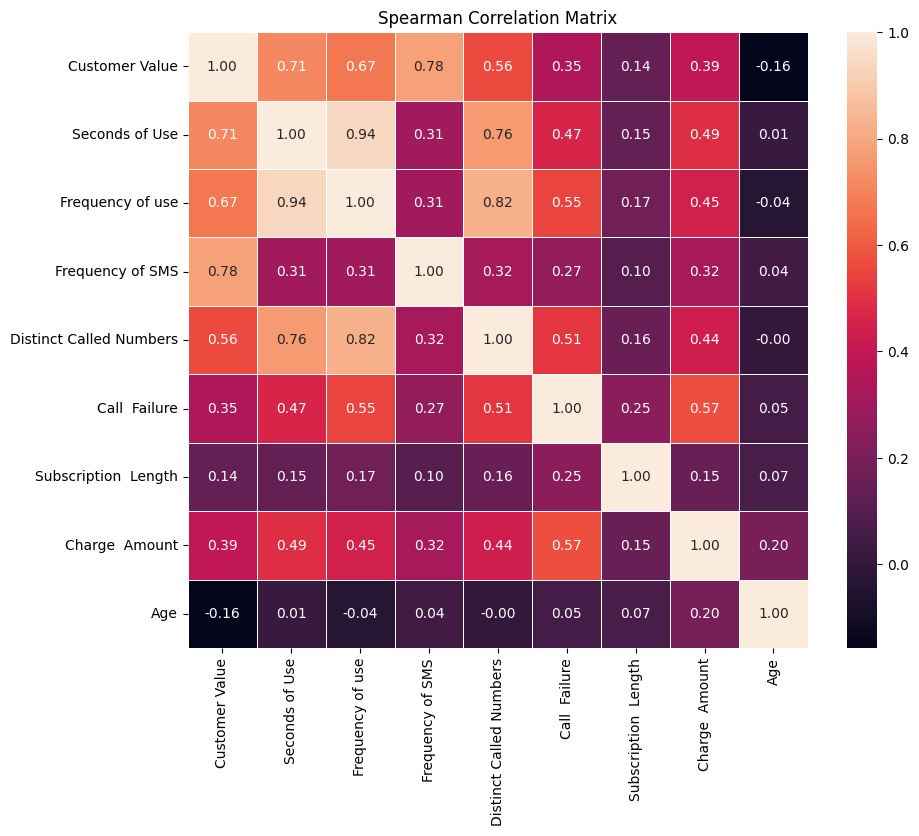

In [187]:
correlation_matrix = data_linear.corr(method='spearman')
print("Spearman Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Matrix')
plt.show()

Spearmanova korelacija pogodna je kada podaci ne prate normalnu distribuciju ili kada veza između varijabli nije strogo linearna.
Budući da su raniji testovi pokazali da podaci nisu normalno distribuirani, Spearmanova korelacija daje dodatni uvid u povezanost varijabli.

S obzirom da varijabla Frequency of SMS ima vrlo visoku povezanost s varijablom Customer Value, odabrat ćemo je kao prediktor za jednostavni linearni model.

In [188]:
def linear_model(X, Y, model_name, x_name):
    print(f"\n--- {model_name} ---")

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

    print(f"Nagib (b1): {slope:.5f}")
    print(f"Odsječak (b0): {intercept:.5f}")
    print(f"Koeficijent korelacije (r): {r_value:.4f}")
    print(f"Koeficijent determinacije (R^2): {r_value**2:.4f}")
    print(f"p-vrijednost: {p_value:.10f}")

    X_sm = sm.add_constant(X)
    model_sm = sm.OLS(Y, X_sm).fit()

    print("\nSummary stats:")
    print(model_sm.summary())

    conf_int_b1 = model_sm.conf_int().loc[x_name]
    print("\n95% interval povjerenja za β1:")
    print(conf_int_b1)

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X, y=Y, alpha=0.3)
    plt.plot(X, intercept + slope * X, color='red', label='Regresijski pravac')
    plt.xlabel(X.name)
    plt.ylabel(Y.name)
    plt.title(f"{model_name} – scatter i regresijska linija")
    plt.legend()
    plt.show()

    y_pred = intercept + slope * X
    residuals = Y - y_pred

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predviđene vrijednosti")
    plt.ylabel("Reziduali")
    plt.title(f"{model_name} – analiza reziduala")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, kde=True)
    plt.title(f"{model_name} – distribucija reziduala")
    plt.xlabel("Reziduali")
    plt.ylabel("Frekvencija")
    plt.show()

    plt.figure()
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"{model_name} – normalni Q-Q graf")
    plt.show()

    pearson_r, pearson_p = stats.pearsonr(X, Y)
    print(f"\nPearsonov koeficijent korelacije: r = {pearson_r:.4f}, p = {pearson_p:.6f}")

    n = len(X)
    F = (r_value**2 / (1 - r_value**2)) * (n - 2)
    p_F = 1 - stats.f.cdf(F, 1, n - 2)
    print(f"F-statistika: {F:.4f}, p-vrijednost: {p_F:.6f}")

    return model_sm


--- Model A: Customer Value ~ Frequency of SMS ---
Nagib (b1): 4.26039
Odsječak (b0): 159.21913
Koeficijent korelacije (r): 0.9249
Koeficijent determinacije (R^2): 0.8554
p-vrijednost: 0.0000000000

Summary stats:
                            OLS Regression Results                            
Dep. Variable:         Customer Value   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                 1.862e+04
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:50:39   Log-Likelihood:                -21105.
No. Observations:                3150   AIC:                         4.221e+04
Df Residuals:                    3148   BIC:                         4.223e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                     

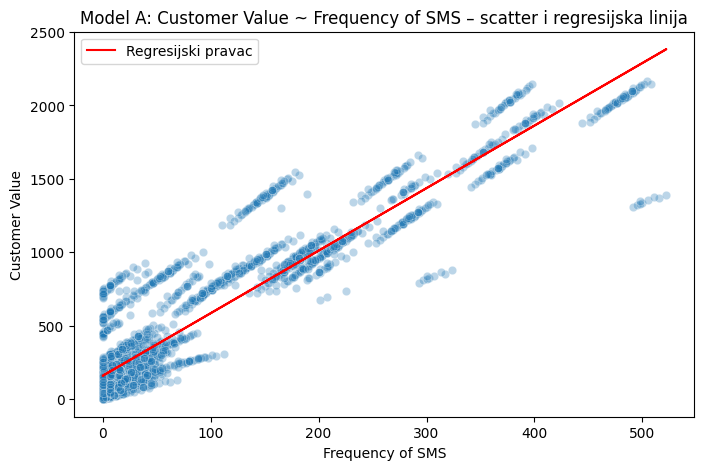

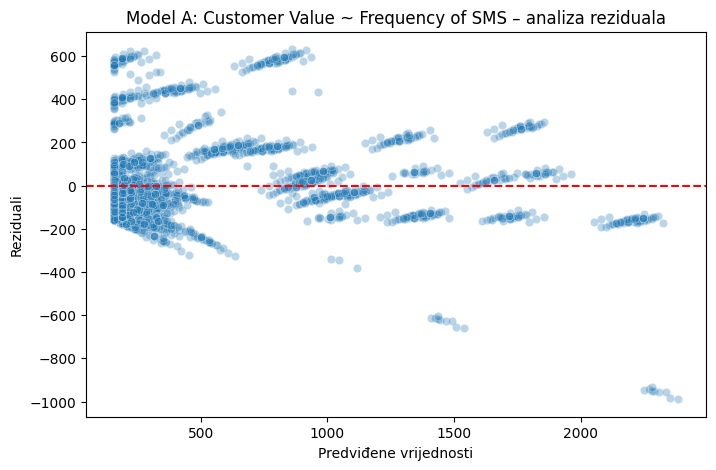

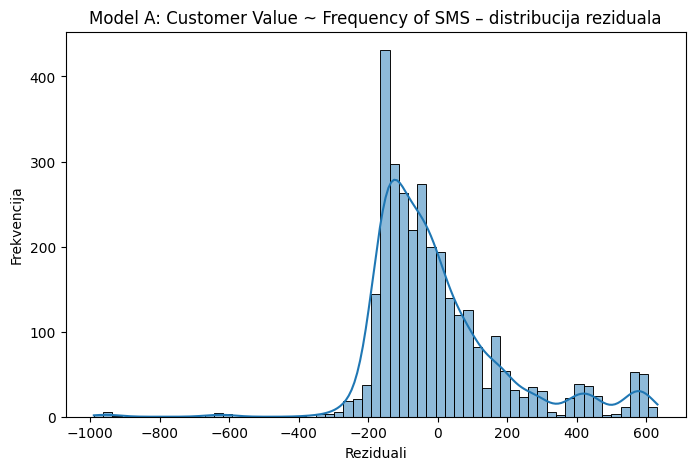

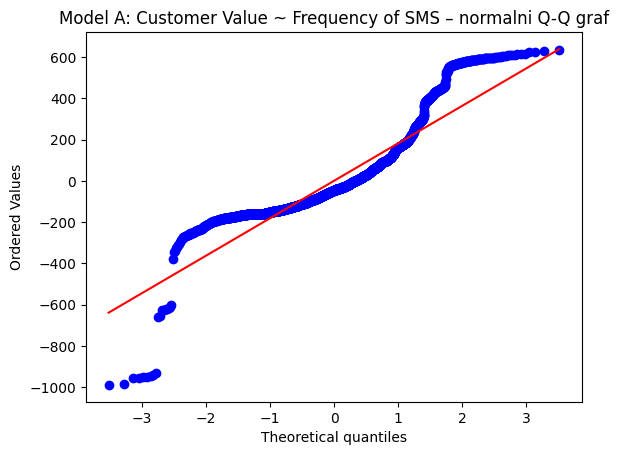


Pearsonov koeficijent korelacije: r = 0.9249, p = 0.000000
F-statistika: 18622.1381, p-vrijednost: 0.000000


In [189]:
X_A = data['Frequency of SMS']
Y_A = data['Customer Value']

modelA_sm = linear_model(X_A, Y_A, "Model A: Customer Value ~ Frequency of SMS", "Frequency of SMS")

Iz jednostavnog linearnog modela možemo vidjeti kako se Customer Value mijenja ovisno o Frequency of SMS.
Nagib regresijskog pravca pokazuje za koliko se u prosjeku mijenja vrijednost korisnika kada se Frequency of SMS poveća za jednu jedinicu.
P-vrijednost se koristi za provjeru je li prediktor statistički značajan.
Koeficijent determinacije R^2 pokazuje koliki dio varijabilnosti zavisne varijable model objašnjava.

Dodatno za izradu složenijeg linearnog modela možemo izračunati multikolinearnost pomoću VIF-a kako bismo provjerili međusobnu povezanost više prediktora.

In [190]:
chosen_variables = ['Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Call  Failure', 'Subscription  Length', 'Charge  Amount', 'Age']

x = data[chosen_variables]

vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)

                   feature        VIF
0           Seconds of Use  26.668801
1         Frequency of use  38.022321
2         Frequency of SMS   1.490868
3  Distinct Called Numbers   6.749803
4            Call  Failure   5.057994
5     Subscription  Length   9.396738
6           Charge  Amount   2.974452
7                      Age   8.211868


Ako je VIF vrijednost veća, postoji veća razina multikolinearnosti između prediktora.
U slučaju jako visoke vrijednosti VIF-a potrebno je razmotriti izbacivanje varijable iz modela.

                            OLS Regression Results                            
Dep. Variable:         Customer Value   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 2.021e+04
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:50:40   Log-Likelihood:                -17913.
No. Observations:                3150   AIC:                         3.584e+04
Df Residuals:                    3141   BIC:                         3.590e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

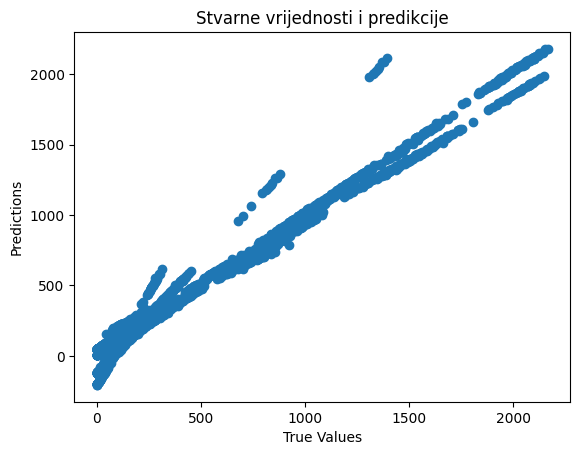

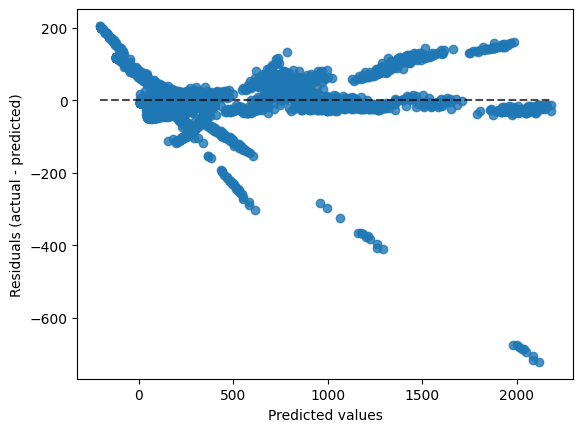

In [191]:
y = data['Customer Value']
X = x.copy()

X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm)
result = model.fit()
print(result.summary())

predictions = result.predict(X_sm)

plt.scatter(y, predictions)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Stvarne vrijednosti i predikcije')
plt.show()

display = PredictionErrorDisplay(y_true=y, y_pred=predictions)
display.plot()
plt.show()

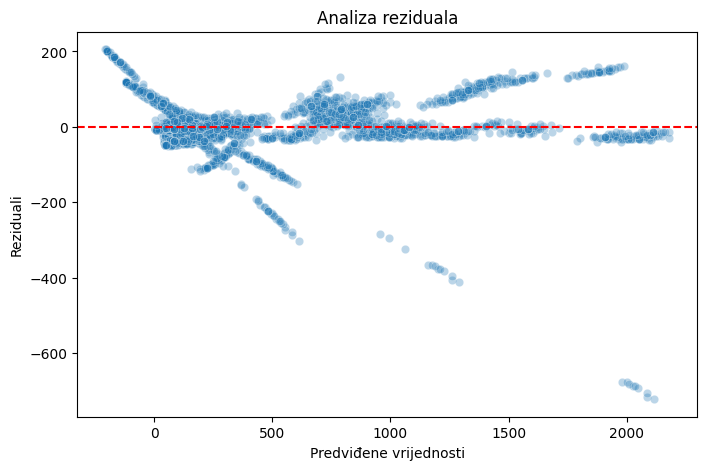

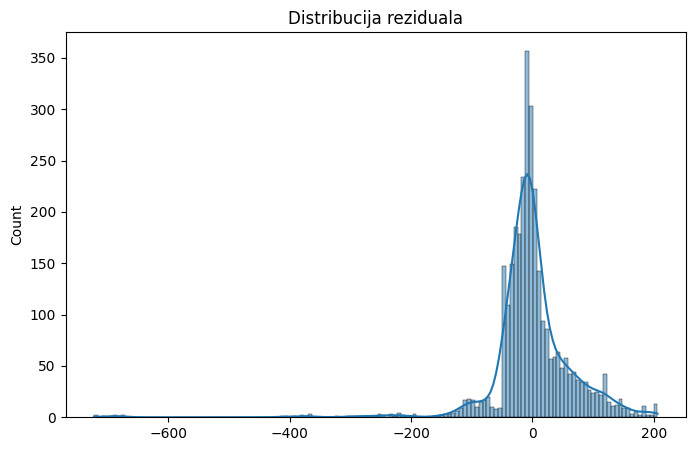

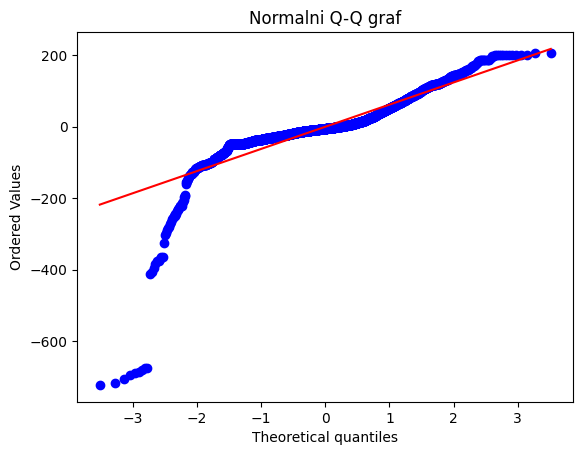

In [192]:
y_pred = result.predict(X_sm)
residuals = y - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predviđene vrijednosti")
plt.ylabel("Reziduali")
plt.title("Analiza reziduala")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribucija reziduala")
plt.show()

plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normalni Q-Q graf')
plt.show()

Iz modela višestruke linearne regresije promatramo p-vrijednosti svakog prediktora i R^2 vrijednost cijelog modela.
Prediktori s p-vrijednošću manjom od 0.05 smatraju se statistički značajnima.
Analizom reziduala provjerava se koliko dobro model opisuje podatke.

# Analiza varijance

In [193]:
!pip install scikit-posthocs

In [194]:
import scikit_posthocs as sp

from scipy import stats
from scipy.stats import f_oneway, shapiro, levene, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

Dodatno možemo raditi analizu razlika između grupa unutar Age Group varijable.
Cilj je ispitati razlikuje li se Customer Value između različitih dobnih skupina.

Potrebno je prvo grupirati podatke.
Grupiramo podatke prema vrijednosti Customer Value i grupama unutar Age Group varijable.
Zatim ispitujemo normalnost podataka jer je normalnost jedan od uvjeta za One-Way ANOVA-u.

In [195]:
groups = [
    data[data['Age Group'] == q]['Customer Value']
    for q in data['Age Group'].unique()
]

for quality in data['Age Group'].unique():
    print(quality)

for i, group in enumerate(groups):
    stat, p = shapiro(group)
    print(f"Grupa {i+1}: p-vrijednost = {p}")

3
2
1
4
5
Grupa 1: p-vrijednost = 1.1607089100897353e-37
Grupa 2: p-vrijednost = 3.295526791090369e-30
Grupa 3: p-vrijednost = 1.2520960559214536e-10
Grupa 4: p-vrijednost = 2.3942391904282226e-26
Grupa 5: p-vrijednost = 3.4848538579390416e-06


Ako sve grupe ne prate normalnu distribuciju, tada nije prikladno koristiti One-Way ANOVA-u.
U tom slučaju koristi se neparametarska zamjena, odnosno Kruskal-Wallis test.

In [196]:
stat, p = levene(*groups)
print(f"Levene test p-vrijednost = {p}")

Levene test p-vrijednost = 1.8105276173802096e-55


Leveneov test koristi se za provjeru homogenosti varijanci.
Ako je p-vrijednost manja od 0.05, pretpostavka jednakosti varijanci nije zadovoljena.

In [197]:
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis test p-vrijednost = {p}")
print(stat)

Kruskal-Wallis test p-vrijednost = 3.563811935704567e-53
251.2145382285072


Kruskal-Wallis test provjerava postoji li statistički značajna razlika između više nezavisnih skupina.
Nulta hipoteza je da su srednje vrijednosti, odnosno distribucije grupa jednake.
Ako je p-vrijednost manja od 0.05, odbacujemo nultu hipotezu i zaključujemo da postoji statistički značajna razlika između barem dvije skupine.

In [198]:
dunn_result = sp.posthoc_dunn(groups, p_adjust='holm')
print(dunn_result)
print(dunn_result < 0.05)

              1             2             3             4             5
1  1.000000e+00  8.994666e-03  2.642389e-01  4.298351e-33  4.657864e-30
2  8.994666e-03  1.000000e+00  8.601366e-01  5.687356e-21  5.532113e-22
3  2.642389e-01  8.601366e-01  1.000000e+00  4.816761e-07  9.329999e-11
4  4.298351e-33  5.687356e-21  4.816761e-07  1.000000e+00  2.095344e-02
5  4.657864e-30  5.532113e-22  9.329999e-11  2.095344e-02  1.000000e+00
       1      2      3      4      5
1  False   True  False   True   True
2   True  False  False   True   True
3  False  False  False   True   True
4   True   True   True  False   True
5   True   True   True   True  False


Nakon značajnog Kruskal-Wallis testa koristi se post-hoc analiza kako bi se provjerilo između kojih grupa postoji statistički značajna razlika.
Dunnov test s Holm korekcijom koristi se kao neparametarska post-hoc metoda.

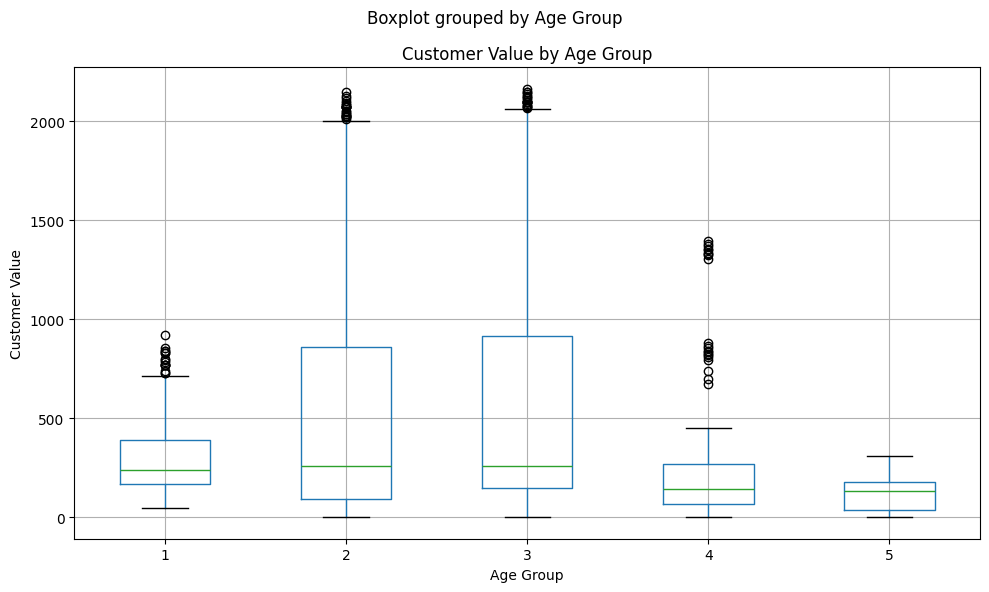

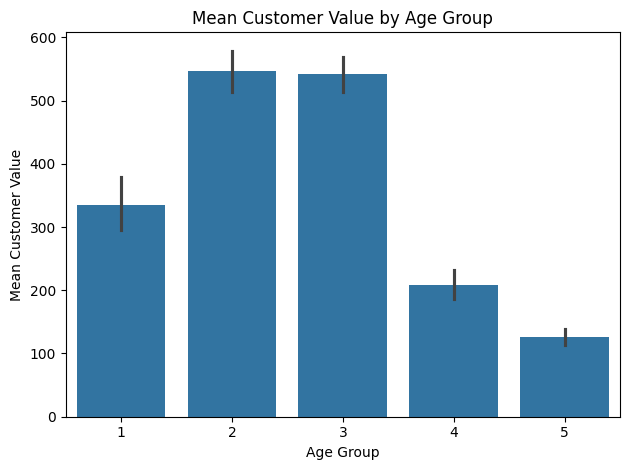

In [199]:
boxplot = data.boxplot(column='Customer Value', by='Age Group', figsize=(10, 6))
plt.title('Customer Value by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customer Value')
plt.tight_layout()
plt.show()

sns.barplot(x='Age Group', y='Customer Value', data=data)
plt.title('Mean Customer Value by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mean Customer Value')
plt.tight_layout()
plt.show()

In [200]:
for group in groups:
    n = group.count()
    standardna_devijacija = np.std(group, ddof=0)
    razina_pouzdanosti = 0.95
    alfa = 1 - razina_pouzdanosti
    t_vrijednost = stats.t.ppf(1 - alfa / 2, df=n-1)

    margina_pogreske = t_vrijednost * (standardna_devijacija / np.sqrt(n-1))
    srednja_vrijednost = group.mean()
    donja_granica = srednja_vrijednost - margina_pogreske
    gornja_granica = srednja_vrijednost + margina_pogreske

    print(f"95% interval povjerenja: ({donja_granica:.2f},{gornja_granica:.2f})")

95% interval povjerenja: (513.07,569.80)
95% interval povjerenja: (513.05,581.20)
95% interval povjerenja: (292.59,376.54)
95% interval povjerenja: (184.09,231.31)
95% interval povjerenja: (112.90,139.53)


Iz provedenih testova možemo zaključiti postoje li statistički značajne razlike u vrijednosti korisnika između dobnih skupina.
Budući da uvjeti normalnosti i homogenosti varijanci nisu zadovoljeni, korišten je Kruskal-Wallis test umjesto One-Way ANOVA-e.

# Zaključak

U ovom radu provedeno je čišćenje podataka, eksplorativna analiza, deskriptivna statistika, statističko zaključivanje, korelacijska analiza, linearna regresija i analiza razlika između više grupa.

Podaci su prvo učitani i očišćeni uklanjanjem dupliciranih redaka i provjerom nedostajućih vrijednosti.
Shapiro-Wilkov test pokazao je da promatrane varijable uglavnom ne prate normalnu distribuciju, zbog čega su korišteni neparametarski testovi.
Mann-Whitney U test korišten je za usporedbu vrijednosti korisnika između korisnika koji su napustili uslugu i korisnika koji nisu napustili uslugu.
Chi-square test korišten je za ispitivanje povezanosti kategoričkih varijabli s odlaskom korisnika.
Korelacijska analiza i linearna regresija korištene su za modeliranje odnosa između korištenja usluge i vrijednosti korisnika.
Na kraju je za usporedbu dobnih skupina korišten Kruskal-Wallis test jer pretpostavke za One-Way ANOVA-u nisu bile zadovoljene.